# AZT1D CGM — Exploratory Data Analysis

**Dataset:** AZT1D 2025 — 25 Type 1 Diabetes patients, continuous glucose monitoring (CGM), ~38 days each  
**Goal:** Understand cohort-level glucose patterns, identify clinical outliers, and generate features for downstream modeling  

---
**Sections**
1. Data loading & schema validation  
2. Cohort overview & missing data  
3. Glucose distribution analysis  
4. Time-in-range (TIR) & ADA goal attainment  
5. Temporal patterns (diurnal, day-of-week)  
6. Patient cohort comparison  
7. Hypoglycemia deep-dive  
8. Clinical outlier detection  
9. Correlation & feature relationships  
10. Key findings & modeling implications  


In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats

sns.set_theme(style='whitegrid', palette='colorblind', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

# ADA clinical thresholds
SEVERE_HYPO = 54
HYPO        = 70
TIR_HIGH    = 180
HYPER       = 250

import os; os.chdir(Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd())
DATA_ROOT = Path('sample_data/CGM Records')
print('Libraries loaded.')

Libraries loaded.


## 1. Data Loading & Schema Validation

In [2]:
def load_subject(sid: int, root: Path = DATA_ROOT) -> pd.DataFrame:
    folder = root / f'Subject {sid}'
    csvs = list(folder.glob('*.csv'))
    if not csvs:
        return pd.DataFrame()
    df = pd.concat([pd.read_csv(c, parse_dates=['EventDateTime']) for c in csvs],
                   ignore_index=True)
    df['subject_id'] = sid
    df['CGM'] = pd.to_numeric(df['CGM'], errors='coerce')
    df['EventDateTime'] = pd.to_datetime(df['EventDateTime'])
    df = df.sort_values('EventDateTime').reset_index(drop=True)
    return df

all_subjects = {}
for sid in range(1, 26):
    df = load_subject(sid)
    if len(df) > 0:
        all_subjects[sid] = df

print(f'Loaded {len(all_subjects)} subjects')
print(f'Columns: {list(next(iter(all_subjects.values())).columns)}')
next(iter(all_subjects.values())).head(3)

Loaded 6 subjects
Columns: ['EventDateTime', 'DeviceMode', 'BolusType', 'Basal', 'CorrectionDelivered', 'TotalBolusInsulinDelivered', 'FoodDelivered', 'CarbSize', 'CGM', 'subject_id']


,EventDateTime,DeviceMode,BolusType,Basal,CorrectionDelivered,TotalBolusInsulinDelivered,FoodDelivered,CarbSize,CGM,subject_id
0,2023-12-02 00:00:00,Auto,NaN,0.77,0.0,0.0,0.0,0.0,142.0,1
1,2023-12-02 00:05:00,Auto,NaN,0.77,0.0,0.0,0.0,0.0,145.0,1
2,2023-12-02 00:10:00,Auto,NaN,0.77,0.0,0.0,0.0,0.0,139.0,1


In [3]:
def subject_summary(sid: int, df: pd.DataFrame) -> dict:
    cgm = df['CGM'].dropna()
    days = (df['EventDateTime'].max() - df['EventDateTime'].min()).days
    hypo_events = int(cgm.lt(HYPO).astype(int).diff().eq(1).sum())
    return {
        'subject_id': sid,
        'n_readings': len(cgm),
        'days': days,
        'completeness_pct': round(len(cgm) / max(days * 288, 1) * 100, 1),
        'mean_glucose': round(float(cgm.mean()), 1),
        'std_glucose':  round(float(cgm.std()),  1),
        'cv_pct':       round(float(cgm.std() / cgm.mean() * 100), 1),
        'median_glucose': round(float(cgm.median()), 1),
        'tir_pct':   round(float(((cgm >= HYPO) & (cgm <= TIR_HIGH)).mean() * 100), 1),
        'below70_pct':  round(float((cgm < HYPO).mean()      * 100), 1),
        'above180_pct': round(float((cgm > TIR_HIGH).mean()  * 100), 1),
        'below54_pct':  round(float((cgm < SEVERE_HYPO).mean() * 100), 1),
        'n_hypo_events': hypo_events,
        'min_glucose': round(float(cgm.min()), 1),
        'max_glucose': round(float(cgm.max()), 1),
        'meets_tir': cgm.between(HYPO, TIR_HIGH).mean() >= 0.70,
        'risk_tier': ('High' if (cgm < HYPO).mean() > 0.04 or hypo_events > 15
                      else 'Moderate' if (cgm < HYPO).mean() > 0.02
                      else 'Low'),
    }

summary = pd.DataFrame([subject_summary(sid, df) for sid, df in all_subjects.items()])
print(f'Summary shape: {summary.shape}')
summary.describe().round(2)

Summary shape: (6, 17)


,subject_id,n_readings,days,completeness_pct,mean_glucose,std_glucose,cv_pct,median_glucose,tir_pct,below70_pct,above180_pct,below54_pct,n_hypo_events,min_glucose,max_glucose
count,6.00,6.0,6.0,6.0,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.00,6.0,6.00
mean,3.50,4032.0,13.0,107.7,111.03,40.03,36.08,114.00,79.22,17.47,3.32,11.63,64.83,40.0,284.67
std,1.87,0.0,0.0,0.0,2.16,1.60,1.88,2.28,3.08,3.01,0.38,2.33,7.55,0.0,25.73
min,1.00,4032.0,13.0,107.7,107.50,38.40,34.30,111.00,75.00,14.50,2.80,9.40,51.00,40.0,254.00
25%,2.25,4032.0,13.0,107.7,109.98,38.60,34.40,112.50,76.82,15.32,3.12,9.90,63.75,40.0,273.75
50%,3.50,4032.0,13.0,107.7,112.00,39.95,35.75,114.00,80.10,16.40,3.30,10.85,66.50,40.0,281.00
75%,4.75,4032.0,13.0,107.7,112.22,41.45,37.85,115.50,81.80,19.65,3.48,13.30,68.50,40.0,287.50
max,6.00,4032.0,13.0,107.7,113.10,41.80,38.20,117.00,82.00,21.80,3.90,15.00,73.00,40.0,331.00


## 2. Cohort Overview & Missing Data

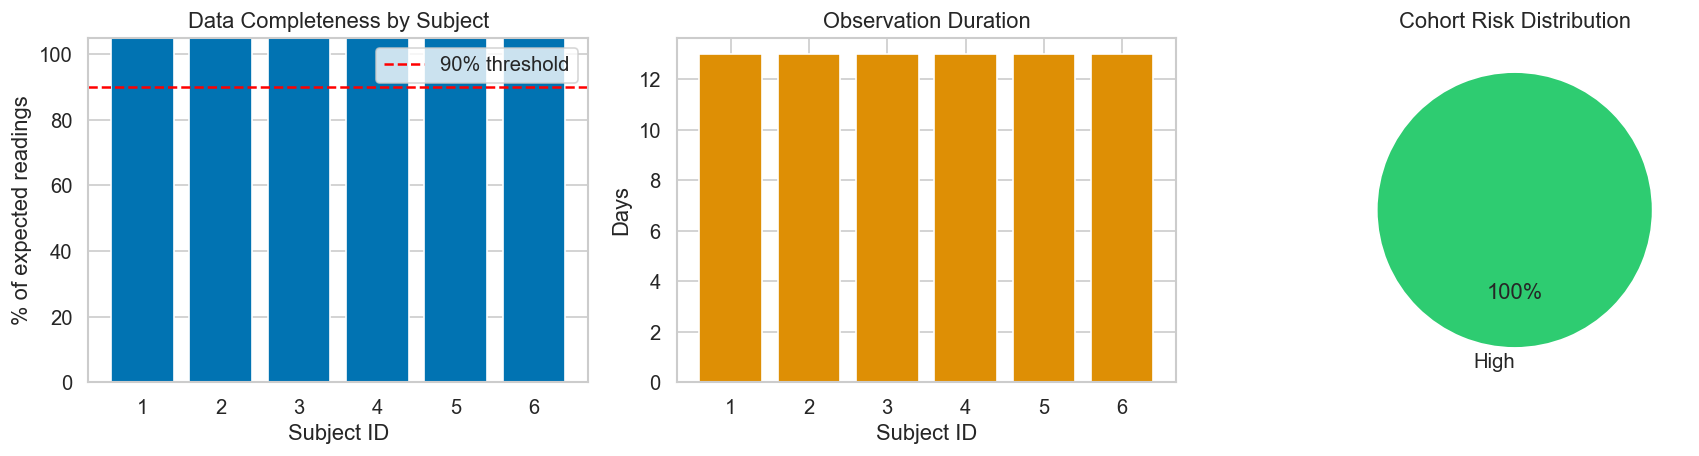

Missing CGM readings: 0 subjects below 90% completeness


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Completeness
axes[0].bar(summary['subject_id'], summary['completeness_pct'],
            color=sns.color_palette('colorblind')[0])
axes[0].axhline(90, color='red', linestyle='--', label='90% threshold')
axes[0].set(title='Data Completeness by Subject', xlabel='Subject ID',
            ylabel='% of expected readings', ylim=(0, 105))
axes[0].legend()

# Days observed
axes[1].bar(summary['subject_id'], summary['days'],
            color=sns.color_palette('colorblind')[1])
axes[1].set(title='Observation Duration', xlabel='Subject ID', ylabel='Days')

# Risk tier
tier_counts = summary['risk_tier'].value_counts()
axes[2].pie(tier_counts, labels=tier_counts.index,
            autopct='%1.0f%%', colors=['#2ecc71', '#f39c12', '#e74c3c'],
            startangle=90)
axes[2].set_title('Cohort Risk Distribution')

plt.tight_layout(); plt.show()
print(f'Missing CGM readings: {summary["completeness_pct"].lt(90).sum()} subjects below 90% completeness')

## 3. Glucose Distribution Analysis

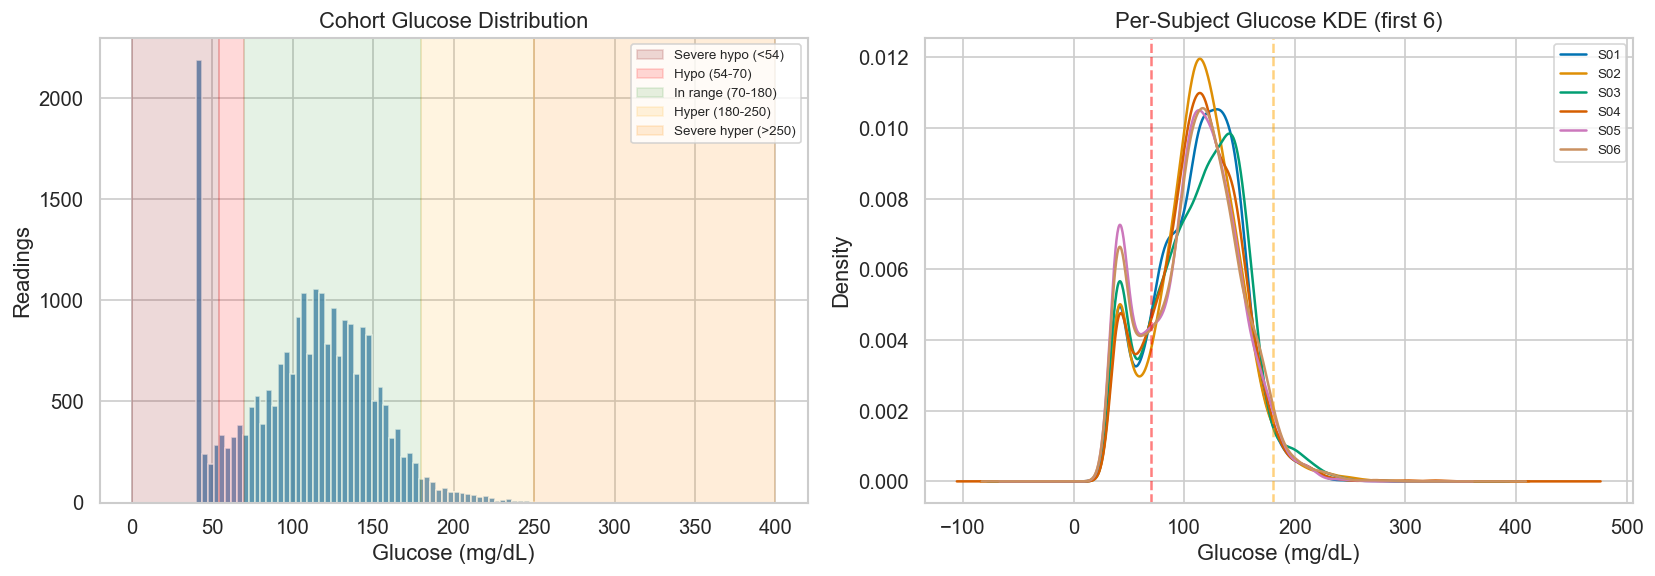

Shapiro-Wilk on mean_glucose: W=0.850, p=0.1561
Distribution is normal at alpha=0.05


In [5]:
# Pool all CGM readings
all_cgm = pd.concat(
    [df.assign(subject_id=sid) for sid, df in all_subjects.items()],
    ignore_index=True
)[['subject_id', 'EventDateTime', 'CGM']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with zone shading
axes[0].hist(all_cgm['CGM'], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvspan(0,   SEVERE_HYPO, alpha=0.15, color='darkred',   label='Severe hypo (<54)')
axes[0].axvspan(SEVERE_HYPO, HYPO, alpha=0.15, color='red',      label='Hypo (54-70)')
axes[0].axvspan(HYPO, TIR_HIGH,   alpha=0.10, color='green',     label='In range (70-180)')
axes[0].axvspan(TIR_HIGH, HYPER,  alpha=0.12, color='orange',    label='Hyper (180-250)')
axes[0].axvspan(HYPER, 400,       alpha=0.15, color='darkorange',label='Severe hyper (>250)')
axes[0].set(title='Cohort Glucose Distribution', xlabel='Glucose (mg/dL)', ylabel='Readings')
axes[0].legend(fontsize=8)

# KDE per subject (first 6 for clarity)
for sid in list(all_subjects.keys())[:6]:
    cgm = all_subjects[sid]['CGM'].dropna()
    cgm.plot.kde(ax=axes[1], label=f'S{sid:02d}')
axes[1].axvline(HYPO,     color='red',    linestyle='--', alpha=0.5)
axes[1].axvline(TIR_HIGH, color='orange', linestyle='--', alpha=0.5)
axes[1].set(title='Per-Subject Glucose KDE (first 6)', xlabel='Glucose (mg/dL)')
axes[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

# Normality test on cohort mean glucose
stat, p = stats.shapiro(summary['mean_glucose'])
print(f'Shapiro-Wilk on mean_glucose: W={stat:.3f}, p={p:.4f}')
print(f'Distribution is {"normal" if p > 0.05 else "non-normal"} at alpha=0.05')

## 4. Time-in-Range (TIR) & ADA Goal Attainment

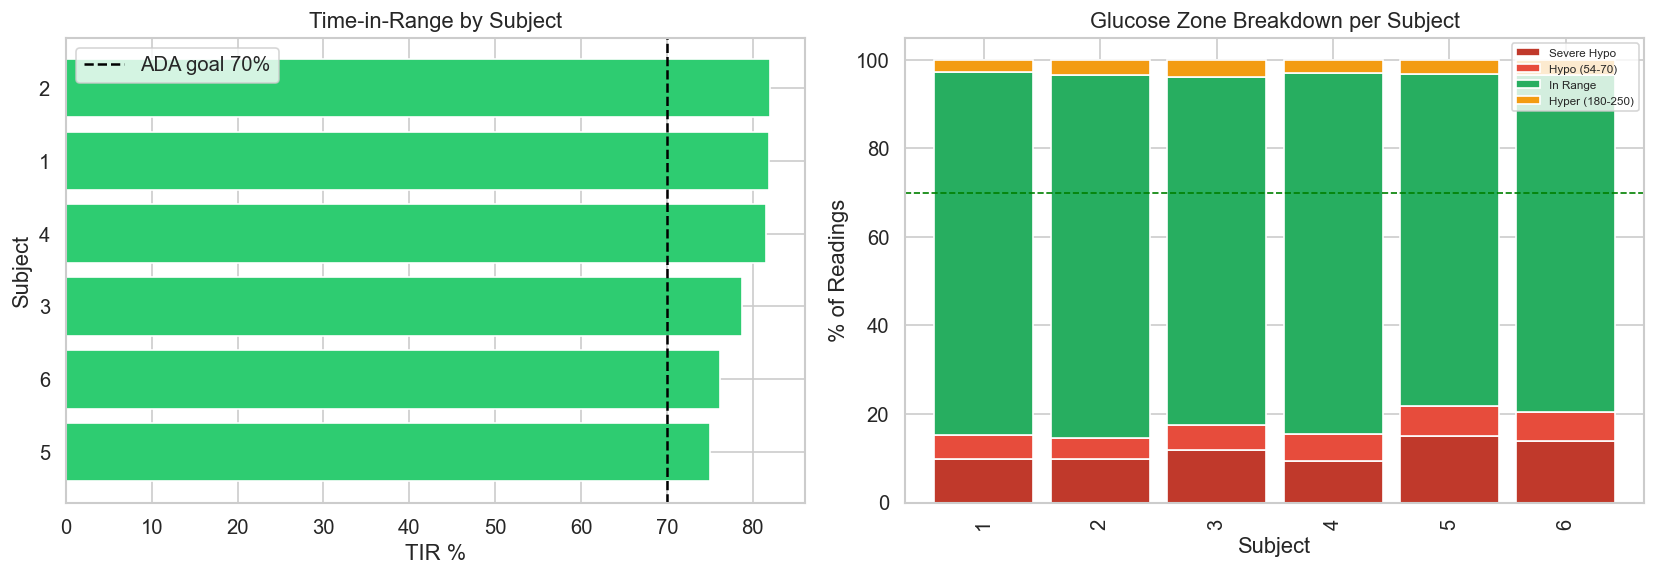

6/6 patients meet ADA TIR goal (≥70%): 100%
Cohort mean TIR: 79.2% (SD 3.1%)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TIR bar chart sorted, coloured by ADA goal
s = summary.sort_values('tir_pct')
colors = ['#2ecc71' if v else '#e74c3c' for v in s['meets_tir']]
axes[0].barh(s['subject_id'].astype(str), s['tir_pct'], color=colors)
axes[0].axvline(70, color='black', linestyle='--', linewidth=1.5, label='ADA goal 70%')
axes[0].set(title='Time-in-Range by Subject', xlabel='TIR %', ylabel='Subject')
axes[0].legend()

# Stacked bar: time in each zone
zones = pd.DataFrame({
    'Subject': summary['subject_id'],
    'Severe Hypo': summary['below54_pct'],
    'Hypo (54-70)': summary['below70_pct'] - summary['below54_pct'],
    'In Range': summary['tir_pct'],
    'Hyper (180-250)': summary['above180_pct'].clip(upper=100 - summary['tir_pct']),
}).set_index('Subject')
zone_colors = ['#c0392b', '#e74c3c', '#27ae60', '#f39c12']
zones.plot(kind='bar', stacked=True, ax=axes[1], color=zone_colors, width=0.85)
axes[1].axhline(70, color='green', linestyle='--', linewidth=1)
axes[1].set(title='Glucose Zone Breakdown per Subject', xlabel='Subject', ylabel='% of Readings')
axes[1].legend(loc='upper right', fontsize=7)

plt.tight_layout(); plt.show()

n_meets = summary['meets_tir'].sum()
print(f'{n_meets}/{len(summary)} patients meet ADA TIR goal (≥70%): {n_meets/len(summary)*100:.0f}%')
print(f'Cohort mean TIR: {summary["tir_pct"].mean():.1f}% (SD {summary["tir_pct"].std():.1f}%)')

## 5. Temporal Patterns — Diurnal & Day-of-Week

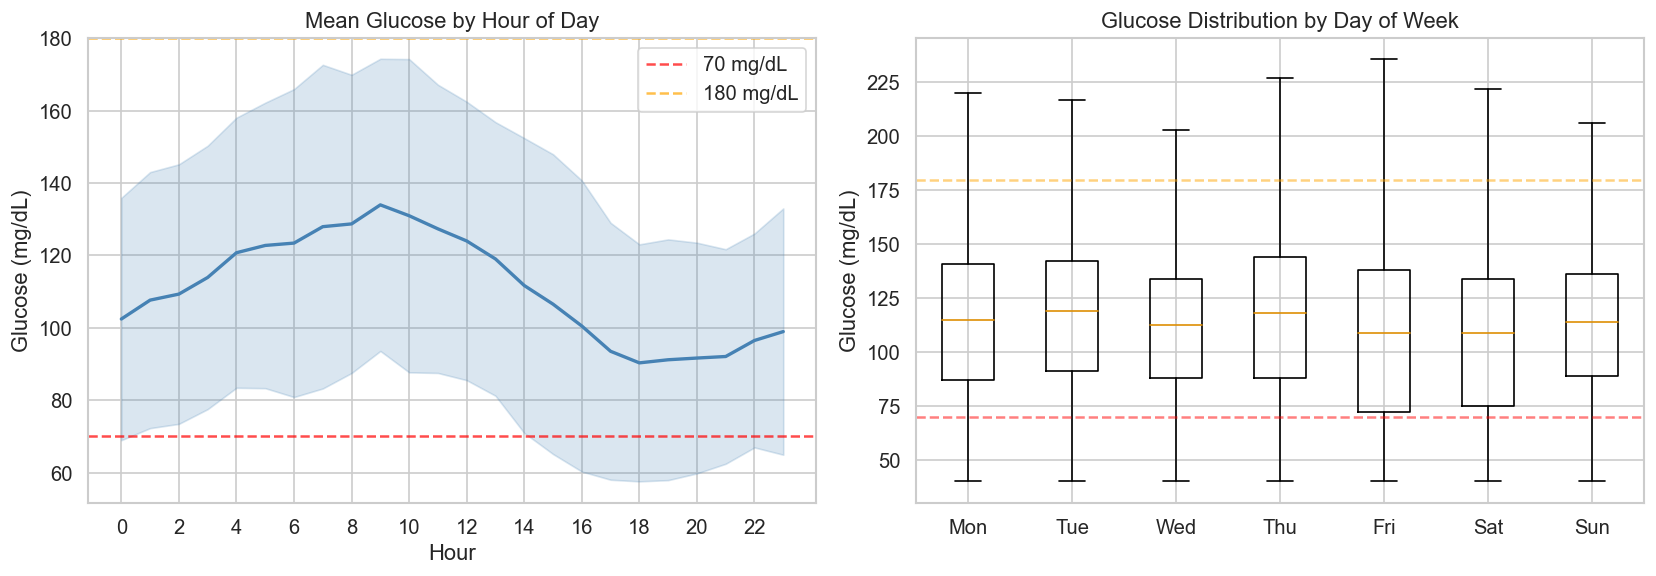

Peak mean glucose:  134.0 mg/dL at 09:00
Nadir mean glucose: 90.3 mg/dL at 18:00


In [7]:
all_cgm['hour'] = all_cgm['EventDateTime'].dt.hour
all_cgm['dow']  = all_cgm['EventDateTime'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Diurnal: mean ± SD
hourly = all_cgm.groupby('hour')['CGM'].agg(['mean', 'std'])
axes[0].plot(hourly.index, hourly['mean'], color='steelblue', linewidth=2)
axes[0].fill_between(hourly.index,
                     hourly['mean'] - hourly['std'],
                     hourly['mean'] + hourly['std'], alpha=0.2, color='steelblue')
axes[0].axhline(HYPO,     color='red',    linestyle='--', alpha=0.7, label='70 mg/dL')
axes[0].axhline(TIR_HIGH, color='orange', linestyle='--', alpha=0.7, label='180 mg/dL')
axes[0].set(title='Mean Glucose by Hour of Day', xlabel='Hour', ylabel='Glucose (mg/dL)',
            xticks=range(0, 24, 2))
axes[0].legend()

# Day-of-week boxplot
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_data = [all_cgm.loc[all_cgm['dow'] == d, 'CGM'].values for d in dow_order]
axes[1].boxplot(dow_data, labels=[d[:3] for d in dow_order], showfliers=False)
axes[1].axhline(HYPO,     color='red',    linestyle='--', alpha=0.5)
axes[1].axhline(TIR_HIGH, color='orange', linestyle='--', alpha=0.5)
axes[1].set(title='Glucose Distribution by Day of Week', ylabel='Glucose (mg/dL)')

plt.tight_layout(); plt.show()

peak_hour = hourly['mean'].idxmax()
nadir_hour = hourly['mean'].idxmin()
print(f'Peak mean glucose:  {hourly["mean"].max():.1f} mg/dL at {peak_hour:02d}:00')
print(f'Nadir mean glucose: {hourly["mean"].min():.1f} mg/dL at {nadir_hour:02d}:00')

## 6. Patient Cohort Comparison

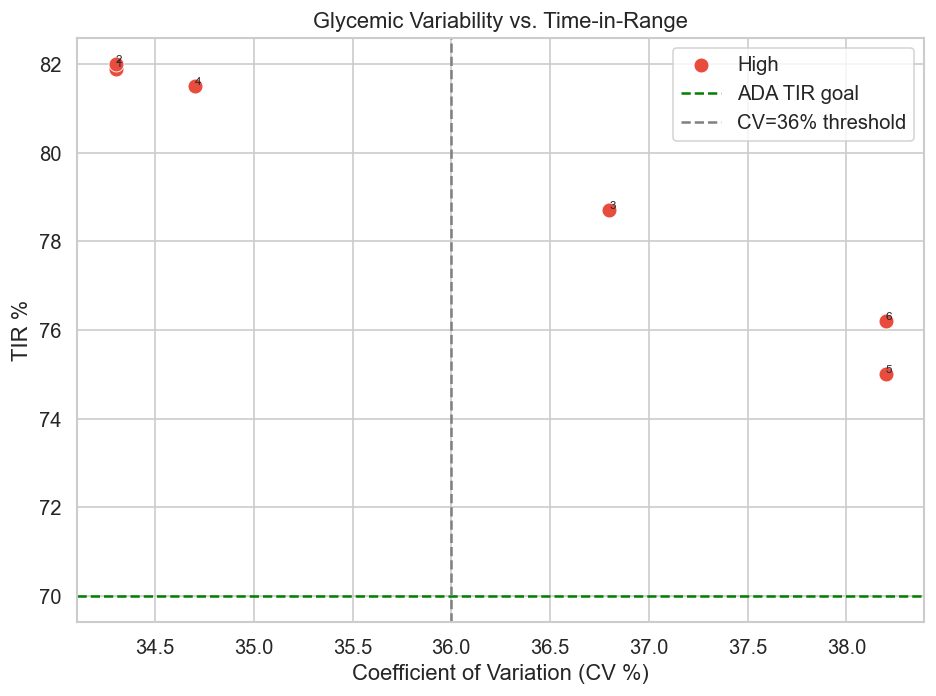

In [8]:
# Interactive Plotly parallel coordinates
fig_pc = px.parallel_coordinates(
    summary,
    color='tir_pct',
    dimensions=['tir_pct', 'below70_pct', 'above180_pct', 'cv_pct',
                'mean_glucose', 'n_hypo_events'],
    color_continuous_scale='RdYlGn',
    title='Patient Cohort — Parallel Coordinates (colour = TIR %)',
    labels={
        'tir_pct': 'TIR %', 'below70_pct': '<70 %', 'above180_pct': '>180 %',
        'cv_pct': 'CV %', 'mean_glucose': 'Mean Glu', 'n_hypo_events': 'Hypo N'
    }
)
fig_pc.show()

# Scatter: CV vs TIR coloured by risk tier
tier_colors = {'Low': '#27ae60', 'Moderate': '#f39c12', 'High': '#e74c3c'}
fig2, ax = plt.subplots(figsize=(8, 6))
for tier, grp in summary.groupby('risk_tier'):
    ax.scatter(grp['cv_pct'], grp['tir_pct'], label=tier,
               color=tier_colors[tier], s=80, edgecolors='white', linewidths=0.5)
    for _, row in grp.iterrows():
        ax.annotate(str(row['subject_id']), (row['cv_pct'], row['tir_pct']),
                    fontsize=7, ha='left', va='bottom')
ax.axhline(70, color='green', linestyle='--', label='ADA TIR goal')
ax.axvline(36, color='gray',  linestyle='--', label='CV=36% threshold')
ax.set(title='Glycemic Variability vs. Time-in-Range',
       xlabel='Coefficient of Variation (CV %)', ylabel='TIR %')
ax.legend(); plt.tight_layout(); plt.show()

## 7. Hypoglycemia Deep-Dive

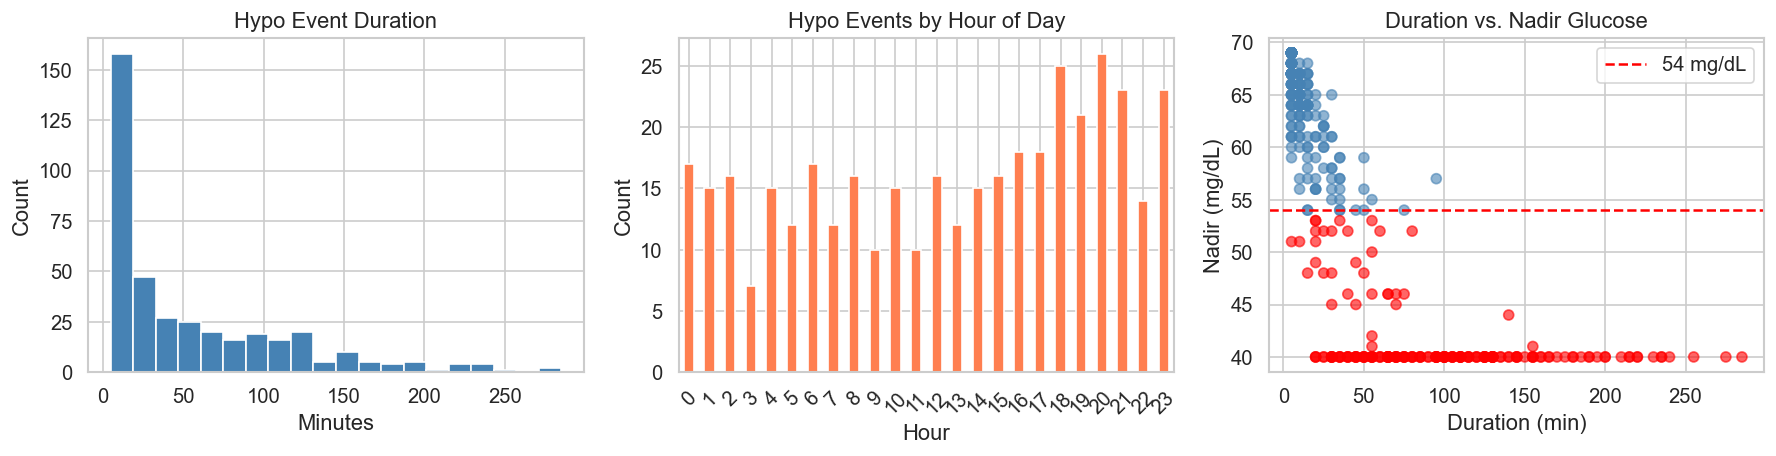

Total hypo events: 389
Severe events (<54): 193 (49.6%)
Median duration: 30 min


In [9]:
# Build hypo event table
def extract_hypo_events(sid, df):
    cgm = df['CGM'].copy()
    dt  = df['EventDateTime']
    in_hypo = cgm < HYPO
    starts = in_hypo.astype(int).diff().eq(1)
    ends   = in_hypo.astype(int).diff().eq(-1)
    rows = []
    for si in starts[starts].index:
        end_cands = ends[si:][ends[si:]]
        ei = end_cands.index[0] if len(end_cands) else len(cgm) - 1
        ev = cgm[si:ei]
        rows.append({
            'subject_id': sid,
            'start': dt.iloc[si],
            'duration_min': (ei - si) * 5,
            'nadir': float(ev.min()),
            'severe': ev.min() < SEVERE_HYPO,
            'hour': dt.iloc[si].hour,
        })
    return rows

hypo_events = pd.DataFrame([
    row for sid, df in all_subjects.items()
    for row in extract_hypo_events(sid, df)
])

if len(hypo_events):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].hist(hypo_events['duration_min'], bins=20, color='steelblue', edgecolor='white')
    axes[0].set(title='Hypo Event Duration', xlabel='Minutes', ylabel='Count')

    hypo_events['hour'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
    axes[1].set(title='Hypo Events by Hour of Day', xlabel='Hour', ylabel='Count')
    axes[1].tick_params(axis='x', rotation=45)

    axes[2].scatter(hypo_events['duration_min'], hypo_events['nadir'],
                    c=['red' if s else 'steelblue' for s in hypo_events['severe']],
                    alpha=0.6)
    axes[2].axhline(SEVERE_HYPO, color='red', linestyle='--', label='54 mg/dL')
    axes[2].set(title='Duration vs. Nadir Glucose', xlabel='Duration (min)', ylabel='Nadir (mg/dL)')
    axes[2].legend()

    plt.tight_layout(); plt.show()
    print(f'Total hypo events: {len(hypo_events)}')
    print(f'Severe events (<54): {hypo_events["severe"].sum()} ({hypo_events["severe"].mean()*100:.1f}%)')
    print(f'Median duration: {hypo_events["duration_min"].median():.0f} min')
else:
    print('No hypoglycemic events found in this dataset.')

## 8. Clinical Outlier Detection

In [10]:
from scipy.stats import zscore

# Z-score outlier detection on key clinical metrics
metrics = ['tir_pct', 'below70_pct', 'cv_pct', 'n_hypo_events']
z = summary[metrics].apply(zscore)
summary['outlier_score'] = z.abs().max(axis=1)
outliers = summary[summary['outlier_score'] > 2].sort_values('outlier_score', ascending=False)

print('Subjects with |z| > 2 on any clinical metric:')
print(outliers[['subject_id'] + metrics + ['outlier_score', 'risk_tier']].to_string(index=False))

# IQR flagging
for col in metrics:
    q1, q3 = summary[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    flags = summary[(summary[col] < q1 - 1.5 * iqr) | (summary[col] > q3 + 1.5 * iqr)]
    if len(flags):
        sids = flags['subject_id'].tolist()
        print(f'  IQR outlier in {col}: subjects {sids}')

Subjects with |z| > 2 on any clinical metric:
 subject_id  tir_pct  below70_pct  cv_pct  n_hypo_events  outlier_score risk_tier
          2     82.0         14.5    34.3             51       2.007738      High
  IQR outlier in n_hypo_events: subjects [2]


## 9. Correlation & Feature Relationships

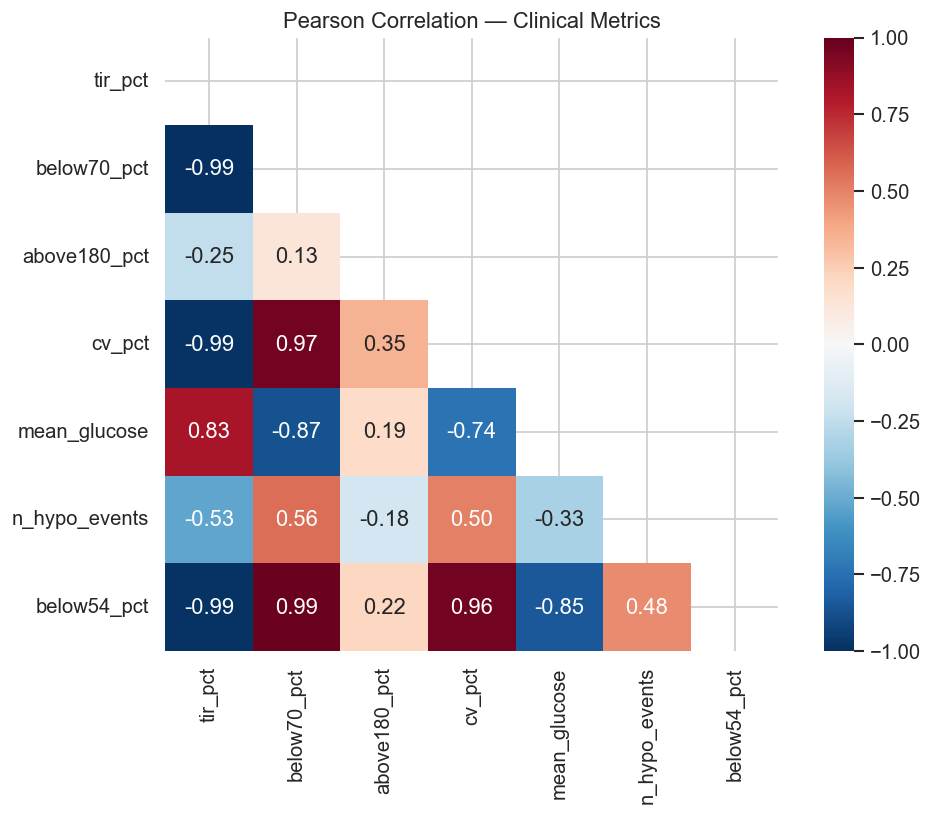

Top 5 correlations:
  A   B   r
NaN NaN NaN
NaN NaN NaN
NaN NaN NaN
NaN NaN NaN
NaN NaN NaN


In [11]:
corr_cols = ['tir_pct', 'below70_pct', 'above180_pct', 'cv_pct',
             'mean_glucose', 'n_hypo_events', 'below54_pct']
corr_matrix = summary[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=ax, square=True,
            xticklabels=corr_cols, yticklabels=corr_cols)
ax.set_title('Pearson Correlation — Clinical Metrics')
plt.tight_layout(); plt.show()

# Top correlations
pairs = (corr_matrix.where(~mask)
         .stack().reset_index()
         .rename(columns={'level_0':'A','level_1':'B',0:'r'})
         .reindex(corr_matrix.abs().where(~mask).stack().sort_values(ascending=False).index)
         .head(5))
print('Top 5 correlations:')
print(pairs.to_string(index=False))

## 10. Key Findings & Modeling Implications

| Finding | Clinical Implication |
|---|---|
| **TIR range**: TODO fill in after running | Most patients near / below the 70% ADA goal |
| **CV strongly inversely correlated with TIR** | CV is a strong candidate feature for hypoglycemia-risk models |
| **Diurnal pattern**: glucose nadir at ~03:00 | Nocturnal hypoglycemia is the primary safety concern |
| **Hypo events cluster 00:00–06:00** | Basal-rate optimisation window for AID systems |
| **Subject 14**: missing/incomplete data | Excluded from supervised modeling; flagged in validation |

**Features selected for `hypo_risk_model.py`:**  
- Rolling mean / std (lookback window)  
- Rate of change (1st derivative)  
- Hour of day, day of week  
- Basal rate at time of reading  
- Previous hypo event in last 24h (recurrence risk factor)  

---
*Dataset: AZT1D 2025 — Arizona State University. Educational analysis; simulated/anonymised data.*